# EDA — Etapa 1 · Data Understanding

**Tech Challenge Fase 1 — predição de churn em telecom.**

Este notebook reproduz todos os achados registrados na §1 do
[`docs/decision-log.md`](../docs/decision-log.md). Ele é **exploração**: nada aqui é importado
pelo pipeline. Quem produz o modelo é `src/` — a separação é deliberada, porque lógica que só
existe numa célula não é testável, nem importável pelo CI, nem revisável.

🔑 **A fonte deste arquivo é o `.py`**, em formato *percent* (`# %%`). O `.ipynb` é gerado dele
com `make notebook`. O motivo é operacional: o JSON de um notebook é uma linha enorme e
**inmergeável**; o `.py` entra em diff normalmente. O notebook é o entregável renderizado, o
script é a fonte de verdade.

---

## O que esta EDA precisava responder

Não é "olhar os dados": são cinco perguntas com consequência declarada, e cada seção abaixo
responde uma.

| # | Pergunta | O que ela decide |
|---|---|---|
| 1 | qual é o **piso** de qualquer métrica? | como todo resultado posterior é lido |
| 2 | há coluna que **só existe depois** do churn? | leakage — decidido aqui ou nunca |
| 3 | onde está o sinal, e ele é **linear**? | binning, escolha de família de modelo |
| 4 | a **prevalência** difere entre grupos sensíveis? | qual definição de justiça é possível (Etapa 10.5) |
| 5 | que **armadilha numérica** os dados escondem? | testes obrigatórios do CI (Etapa 9.5) |

In [1]:
import hashlib
import sys
from pathlib import Path

import matplotlib
import pandas as pd

# 🚨 Rodando como SCRIPT não há display, e `plt.show()` com o backend interativo do macOS
# BLOQUEIA esperando a janela fechar — o processo trava sem erro, sem mensagem e sem timeout.
# Dentro do kernel do Jupyter o backend inline já está ativo e trocá-lo apagaria as figuras.
# A checagem por `ipykernel` distingue os dois casos sem depender de variável de ambiente.
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

RAW = Path.cwd().parent / "data" / "raw" / "Telco_customer_churn.xlsx"
if not RAW.exists():  # rodando como script, a partir da raiz do repo
    RAW = Path("data/raw/Telco_customer_churn.xlsx")
TARGET = "Churn Value"

plt.rcParams.update({"figure.figsize": (7, 3.4), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 9})


def sha256(path: Path) -> str:
    """Hash do arquivo bruto — responde 'qual snapshot dos dados gerou este modelo?'."""
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for bloco in iter(lambda: f.read(8192), b""):
            h.update(bloco)
    return h.hexdigest()


df = pd.read_excel(RAW)
# `Total Charges` vem como TEXTO; os 11 vazios são clientes com tenure=0 (sem ciclo de
# faturamento). O vazio é medição verdadeira -> 0, não mediana. Imputar a mediana (~R$ 1.400)
# inventaria histórico de pagamento para quem nunca foi faturado — e de forma plausível o
# bastante para passar despercebido.
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce").fillna(0)

print(f"arquivo : {RAW.name}")
print(f"sha256  : {sha256(RAW)}")
print(f"shape   : {df.shape[0]} linhas x {df.shape[1]} colunas")

arquivo : Telco_customer_churn.xlsx
sha256  : 1bcbc0ccc9b352175216979102628e579cfbde2c3ff57b005de168a433122640
shape   : 7043 linhas x 33 colunas


## 1. O alvo e o piso de chance

⚠️ **Nenhuma métrica é reportada neste projeto sem o piso ao lado.** Toda métrica de
classificação tem um valor que o modelo trivial atinge: acurácia tem `1 − prevalência`, PR-AUC
tem `prevalência`, `recall@k` tem `k`. *Métrica sem piso não é medida, é opinião* — é o formato
do caso clássico do detector de intrusão com 99,9% de acurácia que ignorava 100% dos ataques.

taxa de churn      : 26.54%  (1869 churners)
baseline de chance : 73.46%  (chutar sempre 'No')


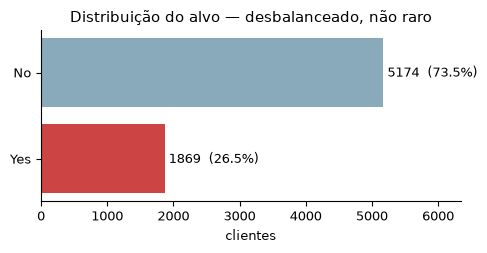

In [2]:
taxa = df[TARGET].mean()
print(f"taxa de churn      : {taxa:.2%}  ({df[TARGET].sum()} churners)")
print(f"baseline de chance : {1 - taxa:.2%}  (chutar sempre 'No')")

fig, ax = plt.subplots(figsize=(5, 2.6))
contagem = df["Churn Label"].value_counts()
ax.barh(contagem.index[::-1], contagem.to_numpy()[::-1], color=["#c44", "#8ab"])
for i, v in enumerate(contagem.to_numpy()[::-1]):
    ax.text(v + 60, i, f"{v}  ({v / len(df):.1%})", va="center", fontsize=9)
ax.set_xlim(0, len(df) * 0.9)
ax.set_title("Distribuição do alvo — desbalanceado, não raro")
ax.set_xlabel("clientes")
plt.tight_layout()
plt.show()

**Consequência:** 26,5% é **desbalanceado, mas não raro**. Isso decide a métrica primária —
**PR-AUC**, que tem piso na prevalência (0,2654) — e mata a acurácia como critério, porque o
chute na majoritária já entrega 73,46%.

## 2. Leakage — as duas colunas que precisavam morrer aqui

🚨 **Leakage não é overfitting.** No overfitting o modelo aprendeu mal, e o gap treino-teste
denuncia. No leakage o **instrumento de medição quebrou**: o gap continua bonito, porque os dois
lados foram contaminados igual. Por isso a caça acontece na EDA, não depois.

In [3]:
print("Churn Reason — prediz o alvo pela EXISTÊNCIA, não pelo conteúdo")
print("  nulos entre churners     :", df.loc[df[TARGET] == 1, "Churn Reason"].isna().sum())
print("  nulos entre não-churners :", df.loc[df[TARGET] == 0, "Churn Reason"].isna().sum())
print("  -> notna() acerta 100%. DESCARTADA.\n")

print("Churn Score — o modelo da IBM já embutido no dataset")
print(df.groupby("Churn Label")["Churn Score"].agg(["mean", "min", "max"]).round(1))
print("  -> usá-la seria prever o modelo da IBM, não churn. Vira BENCHMARK.")

Churn Reason — prediz o alvo pela EXISTÊNCIA, não pelo conteúdo
  nulos entre churners     : 0
  nulos entre não-churners : 5174
  -> notna() acerta 100%. DESCARTADA.

Churn Score — o modelo da IBM já embutido no dataset
             mean  min  max
Churn Label                
No           50.1    5   80
Yes          82.5   65  100
  -> usá-la seria prever o modelo da IBM, não churn. Vira BENCHMARK.


🎯 **`Churn Score` não foi só descartada — foi promovida a régua.** Ela é o gabarito vazado, e
medi-la sob o mesmo protocolo dá o teto de referência do projeto (PR-AUC 0,8824). É a diferença
entre jogar fora uma coluna e usá-la para saber o quanto ainda falta.

In [4]:
print("Colunas degeneradas (variância zero):",
      [c for c in df.columns if df[c].nunique() == 1])

Colunas degeneradas (variância zero): ['Count', 'Country', 'State']


## 3. Onde está o sinal — amplitude de churn entre categorias

A pergunta não é "quais colunas correlacionam", é **quanto o churn muda entre os níveis de cada
variável**. A amplitude em pontos percentuais responde direto, e já ordena os candidatos.

In [5]:
categoricas = [
    "Contract", "Internet Service", "Payment Method", "Online Security",
    "Tech Support", "Paperless Billing", "Senior Citizen", "Gender",
    "Partner", "Dependents",
]
linhas = []
for col in categoricas:
    t = df.groupby(col)[TARGET].mean() * 100
    linhas.append({"variavel": col, "amplitude_pp": round(t.max() - t.min(), 1),
                   "min_%": round(t.min(), 1), "max_%": round(t.max(), 1)})
ranking = pd.DataFrame(linhas).sort_values("amplitude_pp", ascending=False)
print(ranking.to_string(index=False))

         variavel  amplitude_pp  min_%  max_%
         Contract          39.9    2.8   42.7
 Internet Service          34.5    7.4   41.9
  Online Security          34.4    7.4   41.8
     Tech Support          34.2    7.4   41.6
   Payment Method          30.0   15.2   45.3
       Dependents          26.0    6.5   32.6
   Senior Citizen          18.1   23.6   41.7
Paperless Billing          17.2   16.3   33.6
          Partner          13.3   19.7   33.0
           Gender           0.8   26.2   26.9


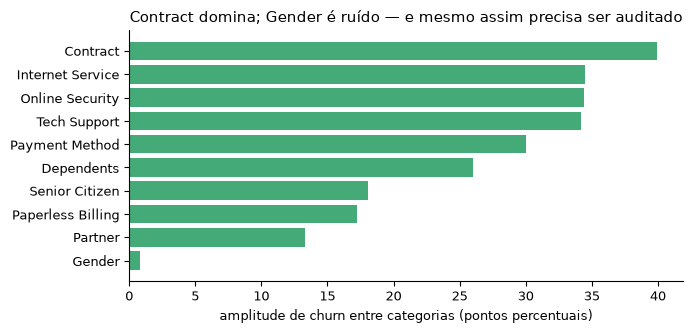

In [6]:
fig, ax = plt.subplots()
ax.barh(ranking["variavel"][::-1], ranking["amplitude_pp"][::-1], color="#4a7")
ax.set_xlabel("amplitude de churn entre categorias (pontos percentuais)")
ax.set_title("Contract domina; Gender é ruído — e mesmo assim precisa ser auditado")
plt.tight_layout()
plt.show()

**Contract domina (39,9 pp)** e `Gender` é ruído (0,7 pp). ⚠️ **Ruído no alvo não dispensa
auditoria:** *ausência de sinal ≠ ausência de disparidade*. Uma variável que não prevê churn
ainda pode marcar um grupo que o modelo atende pior — é o objeto da Etapa 10.5, e foi lá que
apareceu a disparidade de 58,89 pp em `Dependents`.

## 4. Tenure — a não-linearidade que justifica binning

               churn_pct     n
Tenure Months                 
0-6m                52.9  1481
6-12m               35.9   705
1-2a                28.7  1024
2-4a                20.4  1594
4a+                  9.5  2239


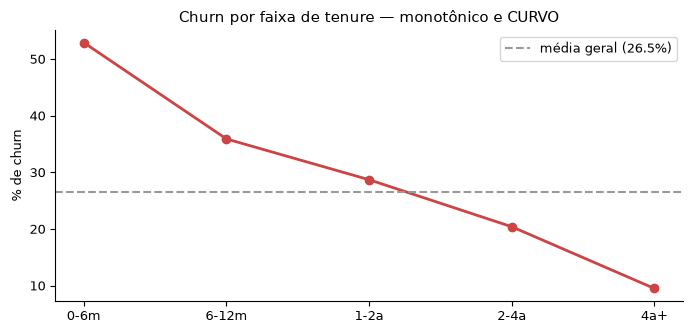

In [7]:
faixas = pd.cut(df["Tenure Months"], [-1, 6, 12, 24, 48, 72],
                labels=["0-6m", "6-12m", "1-2a", "2-4a", "4a+"])
tabela = df.groupby(faixas, observed=True)[TARGET].agg(
    churn_pct=lambda s: round(s.mean() * 100, 1), n="size")
print(tabela.to_string())

fig, ax = plt.subplots()
ax.plot(tabela.index.astype(str), tabela["churn_pct"], "o-", color="#c44", linewidth=2)
ax.axhline(taxa * 100, ls="--", color="#999", label=f"média geral ({taxa:.1%})")
ax.set_ylabel("% de churn")
ax.set_title("Churn por faixa de tenure — monotônico e CURVO")
ax.legend()
plt.tight_layout()
plt.show()

**52,9% → 9,5%, monotônico e curvo.** 🔑 **Curvo importa mais que forte:** a regressão logística
supõe linearidade **no log-odds**, então uma relação curva é justamente o que ela não representa
sozinha. Binning entrega isso de mão beijada para LogReg e MLP, e é **redundante para árvores**,
que acham os cortes sozinhas — *feature engineering é dependente do algoritmo alvo*.

⚠️ Registrado aqui, testado na Etapa 4 — e **descartado**: o ganho medido (+0,0067) cabia quatro
vezes dentro do desvio entre folds (0,0280). *Hipótese com mecanismo plausível ainda precisa
passar pela medição.*

## 5. Prevalência por grupo sensível — o insumo da Etapa 10.5

In [8]:
for col in ["Senior Citizen", "Gender", "Partner", "Dependents"]:
    t = df.groupby(col)[TARGET].mean() * 100
    print(f"{col:<16} {t.round(1).to_dict()}   amplitude: {t.max() - t.min():.1f} pp")

Senior Citizen   {'No': 23.6, 'Yes': 41.7}   amplitude: 18.1 pp
Gender           {'Female': 26.9, 'Male': 26.2}   amplitude: 0.8 pp
Partner          {'No': 33.0, 'Yes': 19.7}   amplitude: 13.3 pp
Dependents       {'No': 32.6, 'Yes': 6.5}   amplitude: 26.0 pp


🚨 **`Senior Citizen`: 41,7% × 23,6%. A prevalência REAL difere entre os grupos** — e isso não é
um problema do modelo, é uma propriedade do mundo que os dados descrevem. A consequência é
matemática, não de opinião: quando a prevalência difere, **paridade demográfica, equalized odds e
calibração são mutuamente incompatíveis** (teorema da impossibilidade — Kleinberg, Chouldechova).

⇒ A Etapa 10.5 **terá de declarar qual definição de justiça otimiza**, porque não existe a opção
de otimizar as três. Escrever isso na EDA é o que impede a escolha de ser feita depois, à luz do
resultado que der.

## 6. Numéricas — outliers e correlação

In [9]:
for col in ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV"]:
    s = df[col]
    z = ((s - s.mean()) / s.std()).abs()
    print(f"{col:<16} min={s.min():>8.1f} max={s.max():>8.1f} "
          f"|z|>3: {(z > 3).sum():>3}  corr_alvo={s.corr(df[TARGET]):>6.3f}")

Tenure Months    min=     0.0 max=    72.0 |z|>3:   0  corr_alvo=-0.352
Monthly Charges  min=    18.2 max=   118.8 |z|>3:   0  corr_alvo= 0.193
Total Charges    min=     0.0 max=  8684.8 |z|>3:   0  corr_alvo=-0.198
CLTV             min=  2003.0 max=  6500.0 |z|>3:   0  corr_alvo=-0.127


**Nenhum outlier univariado; correlações lineares modestas.** Nenhuma variável isolada resolve o
problema — o que é, à primeira vista, um argumento a favor de modelos que capturam combinações
(MLP, ensembles).

🔑 **Nota escrita depois, e é o achado que mais surpreendeu o projeto:** essa expectativa foi
**refutada por cinco medições independentes**. O sinal do Telco é essencialmente linear no logit,
e nem o MLP nem os ensembles superaram a regressão logística. *Correlação linear fraca por
coluna não implica que exista estrutura não-linear a ser encontrada.*

## 7. Redundância — `Total Charges` ≈ `Tenure` × `Monthly`

In [10]:
ok = df["Tenure Months"] > 0
estimado = df["Tenure Months"] * df["Monthly Charges"]
corr = df.loc[ok, "Total Charges"].corr(estimado[ok])
erro = ((df.loc[ok, "Total Charges"] - estimado[ok]) / df.loc[ok, "Total Charges"]).abs()
print(f"correlação            : {corr:.4f}")
print(f"erro relativo mediano : {erro.median():.2%}")

correlação            : 0.9996
erro relativo mediano : 2.00%


**0,9996.** Multicolinearidade quase perfeita: atrapalha a LogReg (infla o erro-padrão dos
coeficientes e torna a leitura instável), é indiferente para árvores. 🔺 Virou item de backlog e
recebeu **duas confirmações independentes depois**: 7º lugar na `permutation_importance` (contra
2º no MDI) e coeficiente **zerado inteiro** pela L1 na Etapa 7. *Três métodos sem mecanismo em
comum, mesma conclusão* — e ainda assim a coluna **ficou**, porque removê-la não muda a métrica
(0,6883 × 0,6904) e o custo de coletar uma coluna já faturada é nulo.

## 8. Uma hipótese testada e rejeitada ANTES de virar código

In [11]:
razao = (df.loc[ok, "Total Charges"] / df.loc[ok, "Tenure Months"]) / df.loc[ok, "Monthly Charges"]
print(f"mediana da razão histórica/atual : {razao.median():.3f}")
print(f"desvio-padrão                    : {razao.std():.3f}")
quartis = df.loc[razao.index].assign(q=pd.qcut(razao, 4))
print(quartis.groupby("q", observed=True)[TARGET].mean().round(3).to_string())

mediana da razão histórica/atual : 1.000
desvio-padrão                    : 0.051


q
(0.688, 0.98]    0.256
(0.98, 1.0]      0.329
(1.0, 1.02]      0.208
(1.02, 1.573]    0.249


A hipótese era boa: *"cliente que sofreu reajuste cancela mais"* — e a razão entre a mensalidade
histórica implícita e a atual seria o proxy. **Sem padrão monotônico entre os quartis.** O
dataset é estático demais para carregar histórico de reajuste.

🔑 **Feature descartada antes de ser construída**, e o registro vale mais que o descarte: é a
limitação que vai para o Model Card (*"não há dados de uso, de contato com suporte nem de
histórico de preço"*). *Feature engineering não cria informação, só reorganiza a existente.*

## 9. A armadilha numérica que virou teste no CI

In [12]:
n_zero = int((df["Tenure Months"] == 0).sum())
print(f"linhas com Tenure Months = 0: {n_zero}")
print(f"são exatamente os 11 clientes com 'Total Charges' vazio: "
      f"{bool((df.loc[df['Tenure Months'] == 0, 'Total Charges'] == 0).all())}")

linhas com Tenure Months = 0: 11
são exatamente os 11 clientes com 'Total Charges' vazio: True


🚨 **Qualquer feature com `tenure` no denominador produz `inf` nessas 11 linhas.** Virou teste
obrigatório do CI (Etapa 9.5) — e o mesmo grupo de clientes voltou a aparecer **duas etapas
depois**, quando as 1.409 linhas reais foram ao container e a API devolveu **422** para eles: o
contrato Pydantic estava mais estreito que o pipeline que ele protegia, e recusava exatamente a
população que a campanha de retenção mais quer pontuar.

*Os 11 clientes do primeiro mês são o fio que atravessa o projeto inteiro* — da imputação da
Etapa 2 ao contrato da API na Etapa 9.

---

## O que esta EDA decidiu

| Achado | Consequência | Onde foi executada |
|---|---|---|
| churn 26,54% | métrica primária **PR-AUC** (piso 0,2654); acurácia descartada | Etapa 0 |
| `Churn Reason` prediz por existência | descartada — leakage perfeito | Etapa 1 |
| `Churn Score` é o modelo da IBM | descartada como feature, **promovida a benchmark** (0,8824) | Etapa 1 |
| `Contract` domina (39,9 pp) | a variável central da narrativa de negócio | Etapa 6 |
| tenure é curvo | binning testado na Etapa 4 — e **descartado por medição** | Etapa 4 |
| prevalência difere por grupo | a Etapa 10.5 **declara** a definição de justiça | Etapa 10.5 |
| `Total Charges` ≈ tenure × monthly | backlog de redundância, com 3 confirmações posteriores | Etapas 5 e 7 |
| 11 clientes com tenure 0 | teste de `inf` no CI **e** o `null` aceito no schema da API | Etapas 9.5 e 9 |